## imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from scipy.interpolate import interp1d

import pandas as pd

## setup model

In [ ]:
# ==========================================
# 1. Spatiotemporal SDF Model
# ==========================================

class TemporalIGRNetwork(nn.Module):
    """
    Inputs: (x, y, t)
    Outputs: Signed Distance
    """
    def __init__(self, hidden_dim=256, num_layers=6):
        super().__init__()
        # Input dim is 3: (x, y, time)
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(3, hidden_dim))

        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))

        self.output = nn.Linear(hidden_dim, 1)
        self.activation = nn.Softplus(beta=100)

        # Initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        for layer in self.layers:
            x = self.activation(layer(x))
        return self.output(x)

class ShorelineEvolutionSDF:
    def __init__(self, hidden_dim=256, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.device = device
        self.model = TemporalIGRNetwork(hidden_dim).to(device)

        # Normalization params
        self.spatial_center = None
        self.spatial_scale = None
        self.time_min = None
        self.time_max = None

    def fit(self, temporal_data, iterations=3000, lr=1e-4):
        """
        temporal_data: Dictionary { day_integer: numpy_array_of_points_Nx2 }
        """
        # 1. Prepare Data & Normalize
        all_points = []
        all_times = []

        for t, pts in temporal_data.items():
            all_points.append(pts)
            all_times.append(np.full((len(pts), 1), t))

        all_points_np = np.vstack(all_points)

        # Calculate Normalization
        self.spatial_center = np.mean(all_points_np, axis=0)
        max_dist = np.max(np.linalg.norm(all_points_np - self.spatial_center, axis=1))
        self.spatial_scale = max_dist * 1.2 # padding

        times = list(temporal_data.keys())
        self.time_min = min(times)
        self.time_max = max(times)
        time_range = max(1.0, self.time_max - self.time_min)

        # Convert boundary points to Normalized Tensor
        # x, y in [-1, 1], t in [-1, 1]
        norm_pts = (all_points_np - self.spatial_center) / self.spatial_scale
        norm_times = (np.vstack(all_times) - self.time_min) / time_range * 2 - 1

        # Input tensor: (N, 3) -> [x, y, t]
        inputs_np = np.hstack([norm_pts, norm_times])
        boundary_tensor = torch.tensor(inputs_np, dtype=torch.float32, device=self.device)
        boundary_tensor.requires_grad_(True)

        optimizer = optim.Adam(self.model.parameters(), lr=lr)

        print(f"Fitting Spatiotemporal SDF on {len(times)} time slices...")

        for i in range(iterations):
            optimizer.zero_grad()

            # --- Loss A: Manifold Constraint (On the shoreline, SDF = 0) ---
            pred_sdf = self.model(boundary_tensor)
            loss_manifold = torch.abs(pred_sdf).mean()

            # --- Loss B: Spatial Eikonal Constraint (|grad_xy| = 1) ---
            # We need to sample random points (x,y) at random times (t)
            # to enforce valid SDF structure everywhere, not just at the boundary.

            n_samples = boundary_tensor.shape[0]

            # Random X,Y in [-1, 1]
            rand_xy = (torch.rand((n_samples, 2), device=self.device) * 2 - 1)
            # Random T in [-1, 1]
            rand_t = (torch.rand((n_samples, 1), device=self.device) * 2 - 1)

            domain_samples = torch.cat([rand_xy, rand_t], dim=1).requires_grad_(True)

            # Forward pass on domain samples
            y_domain = self.model(domain_samples)

            # Calculate gradients w.r.t input (x, y, t)
            grads = torch.autograd.grad(
                outputs=y_domain,
                inputs=domain_samples,
                grad_outputs=torch.ones_like(y_domain),
                create_graph=True,
                retain_graph=True,
                only_inputs=True
            )[0]

            # IMPORTANT: We only want the gradient norm of X and Y to be 1.
            # The gradient of T represents velocity/morphing speed.
            # If we force grad_t to be part of the norm, the shape distorts.
            grad_spatial = grads[:, :2] # Take only dx, dy
            grad_norm = grad_spatial.norm(2, dim=1)

            loss_grad = ((grad_norm - 1) ** 2).mean()

            # Combined Loss
            loss = loss_manifold * 100 + loss_grad * 10

            loss.backward()
            optimizer.step()

            if i % 500 == 0:
                print(f"Iter {i}: Loss {loss.item():.5f}")

    def get_shoreline_at_day(self, day_float, n_points=200):
        """
        Extracts the 2D shoreline for ANY day (including missing ones).
        """
        # Normalize the requested time
        time_range = max(1.0, self.time_max - self.time_min)
        t_norm = (day_float - self.time_min) / time_range * 2 - 1

        # Marching Squares Setup
        res = 256
        x = np.linspace(-1.1, 1.1, res)
        y = np.linspace(-1.1, 1.1, res)
        X, Y = np.meshgrid(x, y)

        # Create input grid: X, Y, and constant T
        grid_flat = np.vstack([X.ravel(), Y.ravel()]).T
        t_flat = np.full((grid_flat.shape[0], 1), t_norm)
        input_tensor = torch.tensor(np.hstack([grid_flat, t_flat]), dtype=torch.float32, device=self.device)

        with torch.no_grad():
            sdf_field = self.model(input_tensor).cpu().numpy().reshape(res, res)

        # Extract 0-level set
        contours = measure.find_contours(sdf_field, 0.0)

        if len(contours) == 0:
            print(f"Warning: No shoreline found for day {day_float}")
            return None

        # Take longest contour
        raw_contour = max(contours, key=len)

        # Convert Grid -> World Coords
        # measure returns (row, col) -> (y, x)
        r, c = raw_contour[:, 0], raw_contour[:, 1]
        x_w = -1.1 + (c / (res-1)) * 2.2
        y_w = -1.1 + (r / (res-1)) * 2.2

        world_contour = np.column_stack([x_w, y_w]) * self.spatial_scale + self.spatial_center

        # Resample to evenly spaced points
        return self._resample_polygon(world_contour, n_points)

    def _resample_polygon(self, poly, n_points):
        # Ensure closed loop
        if np.linalg.norm(poly[0] - poly[-1]) > 1e-6:
            poly = np.vstack([poly, poly[0]])

        # Calc cumulative distance
        dists = np.linalg.norm(np.diff(poly, axis=0), axis=1)
        cum_dist = np.concatenate([[0], np.cumsum(dists)])

        interpolator = interp1d(cum_dist, poly, axis=0, kind='linear')
        target_dists = np.linspace(0, cum_dist[-1], n_points, endpoint=False)

        return interpolator(target_dists)

## load external island data

In [ ]:
url = "https://github.com/Wzesk/littoral/blob/e35aecfe379207a8ecc49b0c3faf6d3ec5efacf0/toy_island/data_exchange/raw_island_days.csv?raw=true"
#url = "https://raw.githubusercontent.com/Wzesk/littoral/refs/heads/main/toy_island/data_exchange/un_transect_sine_test.csv"
data = pd.read_csv(url)
data.fillna(0, inplace=True)
time = pd.to_datetime(data.iloc[:, 0]).tolist()
spatial_data = np.array([np.array(row[1:], dtype=float) for row in data.itertuples(index=False)])

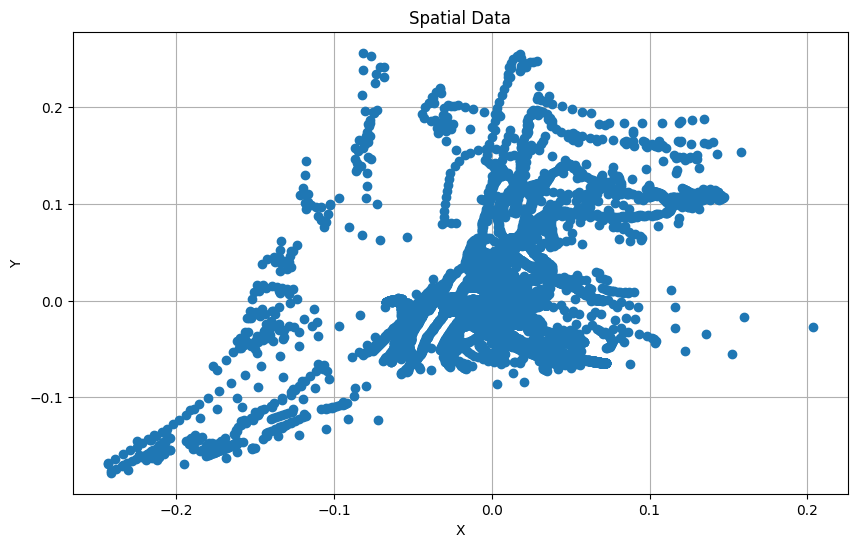

In [ ]:
# normalize and visualize the spatial data
spatial_data = (spatial_data - np.mean(spatial_data, axis=0))
spatial_data = spatial_data / np.max(np.linalg.norm(spatial_data, axis=1))

plt.figure(figsize=(10, 6))
plt.plot(spatial_data[:, 0], spatial_data[:, 1], 'o')
plt.title("Spatial Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

## data generation function

In [ ]:
# ==========================================
# 2. Data Generation (Simulate Steps 1 & 2)
# ==========================================

def generate_wobbly_island(t):
    """Generates a circle that deforms over time using sin waves."""
    theta = np.linspace(0, 2*np.pi, 200)
    base_r = 10.0

    # Frequency and Phase shift over time 't'
    # This simulates erosion/accretion
    r_variance = 1.5 * np.sin(3 * theta + t * 0.1) + \
                 0.5 * np.cos(5 * theta - t * 0.2)

    r = base_r + r_variance
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # # Add some overall drift (translation)
    # x += t * 0.05
    # y += np.sin(t * 0.1) * 0.5

    return np.column_stack([x, y])

## generate islands

In [ ]:
def set_missing_days(all_days, percentage_missing):
    # Calculate the number of days to omit
    num_missing = int(len(all_days) * percentage_missing)

    # Randomly select days to omit without replacement
    missing_days = np.random.choice(all_days, num_missing, replace=False)

    return missing_days

In [ ]:
all_days = np.arange(0, 1000, 5)
missing_days =  set_missing_days(all_days, 0.3)

available_days = [d for d in all_days if d not in missing_days]

data_dict = {}
for day in available_days:
    data_dict[day] = generate_wobbly_island(day)

# plot the generated wobbly islands
plt.figure(figsize=(10, 6))
for day, points in data_dict.items():
    plt.plot(points[:, 0], points[:, 1])#, label=f"Day {day}")
    plt.title("Wobbly Islands")
    plt.xlabel("X")
    plt.ylabel("Y")
    #plt.legend()
    plt.grid(True)
plt.show()

## train

In [ ]:
# B. Train Model
solver = ShorelineEvolutionSDF()
solver.fit(data_dict, iterations=5000)

Fitting Spatiotemporal SDF on 140 time slices...
Iter 0: Loss 11.73822
Iter 500: Loss 2.91350
Iter 1000: Loss 2.04219
Iter 1500: Loss 1.94571
Iter 2000: Loss 1.82406
Iter 2500: Loss 1.79321
Iter 3000: Loss 1.78003
Iter 3500: Loss 1.70169
Iter 4000: Loss 1.69320
Iter 4500: Loss 1.68247


## visualize 2d

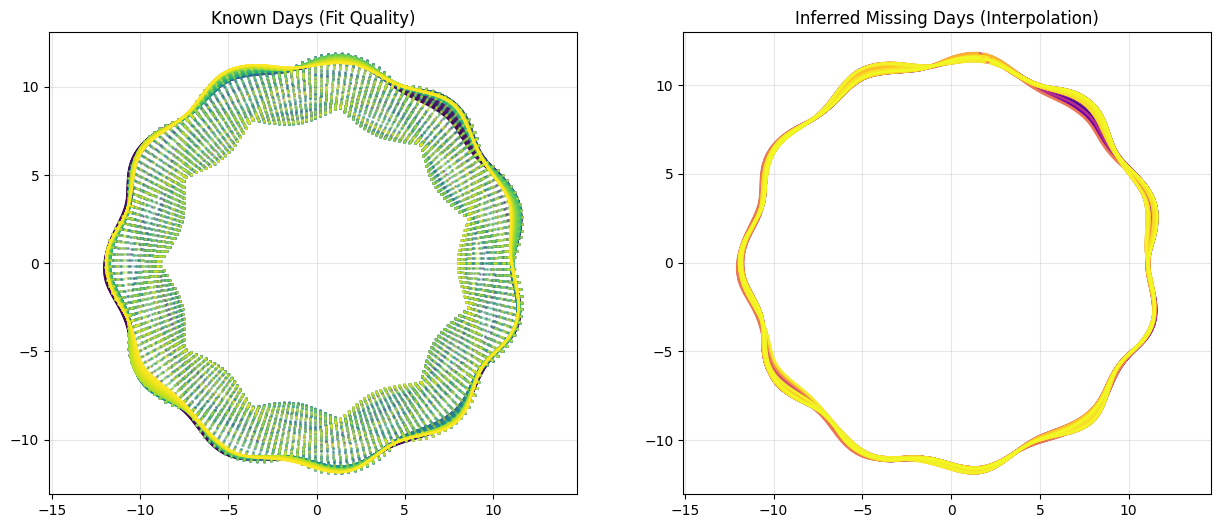

In [ ]:
# C. Visualize Results
plt.figure(figsize=(15, 6))

# Plot 1: Known Days (Ground Truth) vs Reconstruction
plt.subplot(1, 2, 1)
plt.title("Known Days (Fit Quality)")
colors = plt.cm.viridis(np.linspace(0, 1, len(available_days)))
for i, day in enumerate(available_days):
    # GT
    gt = data_dict[day]
    plt.plot(gt[:,0], gt[:,1], '.', color=colors[i], markersize=2, alpha=0.4)
    # Reco
    reco = solver.get_shoreline_at_day(day)
    if reco is not None:
        plt.plot(reco[:,0], reco[:,1], '-', color=colors[i], label=f"Day {day}")
plt.axis('equal')
plt.grid(True, alpha=0.3)

# Plot 2: Inferring Missing Days
plt.subplot(1, 2, 2)
plt.title("Inferred Missing Days (Interpolation)")

# Plot neighbors for context
for day in [5, 20]: # Days around the missing block [10, 15]
    reco = solver.get_shoreline_at_day(day)
    if reco is not None:
        plt.plot(reco[:,0], reco[:,1], '--', color='gray', alpha=0.5, label=f"Known {day}")

# Plot Missing
# FIX: Use a dynamic colormap instead of a fixed list to avoid IndexError
missing_colors = plt.cm.plasma(np.linspace(0, 1, len(missing_days)))

for i, day in enumerate(missing_days):
    reco = solver.get_shoreline_at_day(day)
    if reco is not None:
        plt.plot(reco[:,0], reco[:,1], '-', linewidth=2, color=missing_colors[i], label=f"INFERRED Day {day}")

plt.axis('equal')
# plt.legend() # Legend suppressed as it may be too large
plt.grid(True, alpha=0.3)
plt.show()


##

In [ ]:
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt

# Determine range
max_t = int(max(available_days)) if len(available_days) > 0 else 100
step = max(1, int(max_t / 30)) # Adjust step for density

data = []
print(f"Generating interactive 3D plot for days 0 to {max_t}...")

for t in range(0, max_t + 1, step):
    line = solver.get_shoreline_at_day(t)
    if line is not None:
        # Get color from viridis map
        color_val = plt.cm.viridis(t / max_t)
        color_str = f'rgb({int(color_val[0]*255)}, {int(color_val[1]*255)}, {int(color_val[2]*255)})'

        data.append(go.Scatter3d(
            x=line[:, 0],
            y=line[:, 1],
            z=np.full(line.shape[0], t),
            mode='lines',
            line=dict(color=color_str, width=4),
            name=f'Day {t}',
            showlegend=False
        ))

fig = go.Figure(data=data)
fig.update_layout(
    title="Interactive Spatiotemporal Shoreline Evolution",
    width=1000,
    height=800,
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Time (Days)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1.5) # Stretch z-axis slightly
    )
)
fig.show()

Generating interactive 3D plot for days 0 to 990...
